<a href="https://colab.research.google.com/github/shirin6767saleh/code-/blob/Fnew/graph3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#$\theta=0$

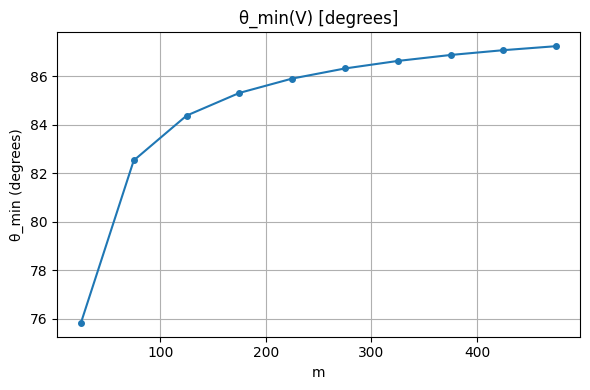

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Utility functions
# ----------------------------
def normalize_column(col):
    return col / np.linalg.norm(col)

def normalize_columns(matrix):
    return np.column_stack([normalize_column(matrix[:, i]) for i in range(matrix.shape[1])])

# ----------------------------
# m values
# ----------------------------
m_values = np.arange(25, 501, 50)
theta_min_vals = []

# ----------------------------
# Main loop
# ----------------------------
for m in m_values:
    N = 4 * m + 2
    p = 0
    t = 2 * p
    w = np.exp(-2j * np.pi / N)

    # Construct Gt
    Gt = np.zeros((N, N), dtype=complex)
    for k in range(N):
        for l in range(N):
            Gt[k, l] = (1/np.sqrt(N)) * w ** ((k - t/2) * (l - t/2))

    # Real and Imag parts
    C = Gt.real
    S = Gt.imag

    # Construct P
    P = 0.5 * np.eye(N)
    P[0, 0] = 1
    P[2*m + 1, 2*m + 1] = 1
    for k in range(1, 2*m + 1):
        P[k, N - k] = 0.5
        P[k + 2*m + 1, N - k - 2*m - 1] = -0.5
    Ph = P
    Ph_inv = np.linalg.inv(Ph)

    # Transform C and S
    V_temp = Ph @ C @ Ph_inv
    W_temp = Ph @ S @ Ph_inv

    A = V_temp[0:2*m+2, 0:2*m+2]
    B = W_temp[2*m+2:N, 2*m+2:N]

    X = A + np.eye(2*m+2)
    Y = A - np.eye(2*m+2)
    Z = B + np.eye(2*m)
    T = B - np.eye(2*m)

    X1 = X[:, :m+1]
    Y1 = Y[:, :m+1]
    Z1 = Z[:, :m]
    T1 = T[:, :m]

    # ----------------------------
    # Correct placement for X2, Y2, Z2, T2 with proper shape N x ...
    # ----------------------------
    X2 = np.zeros((N, m+1))
    X2[:2*m+2, :] = X1

    Y2 = np.zeros((N, m+1))
    Y2[:2*m+2, :] = Y1

    Z2 = np.zeros((N, m))
    Z2[-2*m:, :] = Z1

    T2 = np.zeros((N, m))
    T2[-2*m:, :] = T1

    # Transform back
    X3 = Ph_inv @ X2
    Y3 = Ph_inv @ Y2
    Z3 = Ph_inv @ Z2
    T3 = Ph_inv @ T2

    V = np.hstack([X3, Y3, Z3, T3])

    # ----------------------------
    # Minimum angle
    # ----------------------------
    Vn = normalize_columns(V)
    min_angle = np.pi
    for i in range(Vn.shape[1]):
        for j in range(i + 1, Vn.shape[1]):
            inner = np.clip(np.dot(Vn[:, i], Vn[:, j]), -1.0, 1.0)
            angle = np.arccos(inner)
            if angle < min_angle:
                min_angle = angle
    theta_min_vals.append(np.degrees(min_angle))

# ----------------------------
# Plot
# ----------------------------
plt.figure(figsize=(6, 4))
plt.plot(m_values, theta_min_vals, marker='o', markersize=4)
plt.title("θ_min(V) [degrees]", fontsize=12)
plt.xlabel("m")
plt.ylabel("θ_min (degrees)")
plt.grid(True)
plt.tight_layout()
plt.show()


#check
 $\theta=0$


In [1]:
import numpy as np

# ----------------------------
# Parameters
# ----------------------------
m = 2
N = 4 * m + 2
p = 0
t = 2 * p
w = np.exp(-2j * np.pi / N)

# ----------------------------
# Construct Gt
# ----------------------------
Gt = np.zeros((N, N), dtype=complex)
for k in range(N):
    for l in range(N):
        Gt[k, l] = (1/np.sqrt(N)) * w ** ((k - t/2) * (l - t/2))

# ----------------------------
# Extract real and imaginary parts
# ----------------------------
C = Gt.real
S = Gt.imag

# ----------------------------
# Construct matrix P
# ----------------------------
P = 0.5 * np.eye(N)
P[0, 0] = 1
P[2*m + 1, 2*m + 1] = 1

for k in range(1, 2*m + 1):
    P[k, N - k] = 0.5
    P[k + 2*m + 1, N - k - 2*m - 1] = -0.5

Ph = P

# ----------------------------
# Transform C and S
# ----------------------------
Ph_inv = np.linalg.inv(Ph)
V_temp = Ph @ C @ Ph_inv
W_temp = Ph @ S @ Ph_inv

A = V_temp[0:2*m+2, 0:2*m+2]
B = W_temp[2*m+2:N, 2*m+2:N]

X = A + np.eye(2*m+2)
Y = A - np.eye(2*m+2)
Z = B + np.eye(2*m)
T = B - np.eye(2*m)

X1 = X[:, :m+1]
Y1 = Y[:, :m+1]
Z1 = Z[:, :m]
T1 = T[:, :m]

X2 = np.vstack([X1, np.zeros((m+2, m+1))])
Y2 = np.vstack([Y1, np.zeros((m+2, m+1))])
Z2 = np.vstack([np.zeros((2*m+2, m)), Z1])
T2 = np.vstack([np.zeros((2*m+2, m)), T1])

# ----------------------------
# Transform back by inv(Ph)
# ----------------------------
X3 = Ph_inv @ X2
Y3 = Ph_inv @ Y2
Z3 = Ph_inv @ Z2
T3 = Ph_inv @ T2

V = np.hstack([X3, Y3, Z3, T3])

# ----------------------------
# Define diagonal matrix D
# ----------------------------
D = np.zeros((N, N), dtype=complex)
for k in range(m+1):
    D[k, k] = 1
    D[m+1 + k, m+1 + k] = -1
for k in range(m):
    D[2*m+2 + k, 2*m+2 + k] = 1j
    D[3*m+2 + k, 3*m+2 + k] = -1j

# ----------------------------
# Check Gt @ T3 + i*T3 (like MATLAB)
# ----------------------------
check_T3 = Gt @ T3 + 1j*T3
check_T3[np.abs(check_T3) < 1e-14] = 0

# ----------------------------
# Check final relation Gt @ V - V @ D
# ----------------------------
diff = Gt @ V - V @ D
diff[np.abs(diff) < 1e-14] = 0  # small values to zero

# ----------------------------
# Results
# ----------------------------
is_equal = np.all(diff == 0)
print("Gt @ V equals V @ D? ->", is_equal)


Gt @ V equals V @ D? -> True


#$\theta = 2 * N - 1$

Parameters: m = 25, p = 0, N = 100, theta = 199
Parameters: m = 75, p = 0, N = 300, theta = 599
Parameters: m = 125, p = 0, N = 500, theta = 999
Parameters: m = 175, p = 0, N = 700, theta = 1399
Parameters: m = 225, p = 0, N = 900, theta = 1799
Parameters: m = 275, p = 0, N = 1100, theta = 2199
Parameters: m = 325, p = 0, N = 1300, theta = 2599
Parameters: m = 375, p = 0, N = 1500, theta = 2999
Parameters: m = 425, p = 0, N = 1700, theta = 3399
Parameters: m = 475, p = 0, N = 1900, theta = 3799


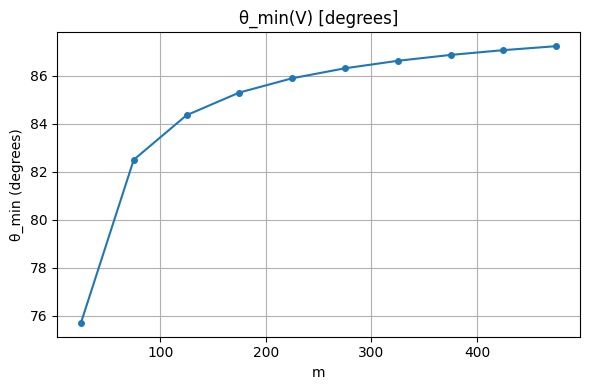

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# === Define m values ===
m_values = np.arange(25, 501, 50)
theta_min_vals = []

# === Utility Functions ===
def normalize_column(col):
    return col / np.linalg.norm(col)

def normalize_columns(matrix):
    return np.column_stack([normalize_column(matrix[:, i]) for i in range(matrix.shape[1])])

# === Loop over all m_values ===
for m in m_values:
    N = 4 * m
    p = 0
    theta = 2 * N - 1
    print(f'Parameters: m = {m}, p = {p}, N = {N}, theta = {theta}')

    # === Compute G_theta ===
    w = np.exp(-2j * np.pi / N)
    G_theta = np.zeros((N, N), dtype=complex)
    for k in range(N):
        for l in range(N):
            exponent = (k - theta / 2) * (l - theta / 2)
            G_theta[k, l] = (1 / np.sqrt(N)) * w**exponent

    # === Identity and G_theta squared ===
    I = np.eye(N)
    G_squared = G_theta @ G_theta

    # === Real and imaginary parts ===
    P = (0.5 * (I + G_squared)).real
    Q = (0.5 * (I - G_squared)).real
    C = G_theta.real
    S = G_theta.imag

    # === Construct Phi ===
    Phi = np.vstack([P[0:2*m, :], Q[2*m:N, :]])
    Phi_inv = np.linalg.inv(Phi)

    result = Phi @ C @ Phi_inv
    result1 = Phi @ S @ Phi_inv

    A = result[0:2*m, 0:2*m]
    B = result1[2*m:N, 2*m:N]

    # === Construct X, Y, Z, T ===
    X = A + np.eye(2*m)
    Y = A - np.eye(2*m)
    Z = B + np.eye(2*m)
    T = B - np.eye(2*m)

    X1 = X[:, 0:m]
    Y1 = Y[:, 0:m]
    Z1 = Z[:, 0:m]
    T1 = T[:, 0:m]

    X2 = np.vstack([X1, np.zeros((2*m, m))])
    Y2 = np.vstack([Y1, np.zeros((2*m, m))])
    Z2 = np.vstack([np.zeros((2*m, m)), Z1])
    T2 = np.vstack([np.zeros((2*m, m)), T1])

    X3 = Phi_inv @ X2
    Y3 = Phi_inv @ Y2
    Z3 = Phi_inv @ Z2
    T3 = Phi_inv @ T2

    V = np.hstack([X3, Y3, Z3, T3])



    # === Compute Minimum Angle θ_min ===
    Vn = normalize_columns(V)
    min_angle = np.pi
    for i in range(Vn.shape[1]):
        for j in range(i + 1, Vn.shape[1]):
            inner = np.clip(np.dot(Vn[:, i], Vn[:, j]), -1.0, 1.0)
            angle = np.arccos(inner)
            if angle < min_angle:
                min_angle = angle

    theta_min_vals.append(np.degrees(min_angle))

# === Plot Minimum Angle ===
plt.figure(figsize=(6, 4))
plt.plot(m_values, theta_min_vals, marker='o', markersize=4)
plt.title("θ_min(V) [degrees]", fontsize=12)
plt.xlabel("m")
plt.ylabel("θ_min (degrees)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [9]:
# === Build D matrix (Python equivalent of MATLAB loop) ===
D = np.zeros((N, N), dtype=complex)
for k in range(m):
    D[k, k] = 1
    D[m + k, m + k] = -1
    D[2*m + k, 2*m + k] = 1j
    D[3*m + k, 3*m + k] = -1j

# === Check equality G_theta - V*D*inv(V) ===
equality_check = G_theta @V -   V @ D
if np.allclose(equality_check, 0, atol=1e-10):
    print(f"m = {m}: The equality holds: G_theta - V*D*inv(V) ≈ 0")
else:
    print(f"m = {m}: The equality does NOT hold")
    print("Maximum deviation:", np.max(np.abs(equality_check)))


m = 475: The equality holds: G_theta - V*D*inv(V) ≈ 0


#$\theta = N - 1$

Parameters: m = 25, p = 0, N = 100, theta = 99
Parameters: m = 75, p = 0, N = 300, theta = 299
Parameters: m = 125, p = 0, N = 500, theta = 499
Parameters: m = 175, p = 0, N = 700, theta = 699
Parameters: m = 225, p = 0, N = 900, theta = 899
Parameters: m = 275, p = 0, N = 1100, theta = 1099
Parameters: m = 325, p = 0, N = 1300, theta = 1299
Parameters: m = 375, p = 0, N = 1500, theta = 1499
Parameters: m = 425, p = 0, N = 1700, theta = 1699
Parameters: m = 475, p = 0, N = 1900, theta = 1899


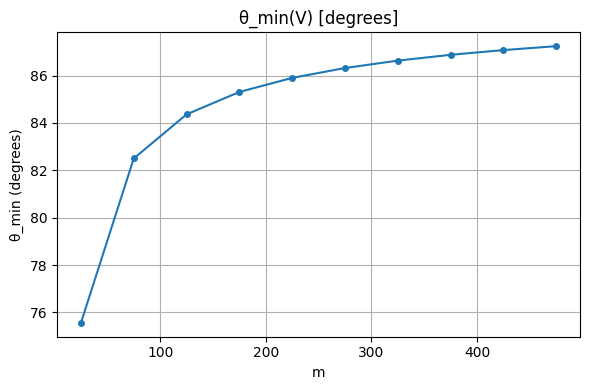

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# === Define m values ===
m_values = np.arange(25, 501, 50)
theta_min_vals = []

# === Utility Functions ===
def normalize_column(col):
    return col / np.linalg.norm(col)

def normalize_columns(matrix):
    return np.column_stack([normalize_column(matrix[:, i]) for i in range(matrix.shape[1])])

# === Loop over all m_values ===
for m in m_values:
    N = 4 * m
    p = 0
    theta = N - 1
    print(f'Parameters: m = {m}, p = {p}, N = {N}, theta = {theta}')

    # === Compute G_theta ===
    w = np.exp(-2j * np.pi / N)
    G_theta = np.zeros((N, N), dtype=complex)
    for k in range(N):
        for l in range(N):
            exponent = (k - theta / 2) * (l - theta / 2)
            G_theta[k, l] = (1 / np.sqrt(N)) * w**exponent

    # === Identity and G_theta squared ===
    I = np.eye(N)
    G_squared = G_theta @ G_theta

    # === P_theta and Q_theta ===
    P_theta = 0.5 * (I + G_squared)
    Q_theta = 0.5 * (I - G_squared)

    # === Extract real and imaginary parts ===
    P = P_theta.real
    Q = Q_theta.real
    C = G_theta.real
    S = G_theta.imag

    # === Construct Phi ===
    Phi = np.vstack([P[0:2*m, :], Q[2*m:N, :]])
    Phi_inv = np.linalg.inv(Phi)

    result = Phi @ C @ Phi_inv
    result1 = Phi @ S @ Phi_inv

    A = result[0:2*m, 0:2*m]
    B = result1[2*m:N, 2*m:N]

    # === Construct matrices X, Y, Z, T ===
    X = A + np.eye(2*m)
    Y = A - np.eye(2*m)
    Z = B + np.eye(2*m)
    T = B - np.eye(2*m)

    X1 = X[:, 0:m]
    Y1 = Y[:, 0:m]
    Z1 = Z[:, 0:m]
    T1 = T[:, 0:m]

    X2 = np.vstack([X1, np.zeros((2*m, m))])
    Y2 = np.vstack([Y1, np.zeros((2*m, m))])
    Z2 = np.vstack([np.zeros((2*m, m)), Z1])
    T2 = np.vstack([np.zeros((2*m, m)), T1])

    X3 = Phi_inv @ X2
    Y3 = Phi_inv @ Y2
    Z3 = Phi_inv @ Z2
    T3 = Phi_inv @ T2

    V = np.hstack([X3, Y3, Z3, T3])


    # === Compute Minimum Angle θ_min ===
    Vn = normalize_columns(V)
    min_angle = np.pi
    for i in range(Vn.shape[1]):
        for j in range(i + 1, Vn.shape[1]):
            inner = np.clip(np.dot(Vn[:, i], Vn[:, j]), -1.0, 1.0)
            angle = np.arccos(inner)
            if angle < min_angle:
                min_angle = angle

    theta_min_vals.append(np.degrees(min_angle))

# === Plot Minimum Angle ===
plt.figure(figsize=(6, 4))
plt.plot(m_values, theta_min_vals, marker='o', markersize=4)
plt.title("θ_min(V) [degrees]", fontsize=12)
plt.xlabel("m")
plt.ylabel("θ_min (degrees)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [11]:
# === Build D matrix ===
D = np.zeros((N, N), dtype=complex)
for k in range(m):
    D[k, k] = 1
    D[m + k, m + k] = -1
    D[2*m + k, 2*m + k] = 1j
    D[3*m + k, 3*m + k] = -1j

# === Check G_theta - V * D * inv(V) ===
equality_check = G_theta @ V -  V @ D
if np.allclose(equality_check, 0, atol=1e-10):
    print(f"m = {m}: The equality holds: G_theta - V*D*inv(V) ≈ 0")
else:
    print(f"m = {m}: The equality does NOT hold")
    print("Maximum deviation:", np.max(np.abs(equality_check)))


m = 475: The equality holds: G_theta - V*D*inv(V) ≈ 0
